In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurações de visualização
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

# Carregar todos os anos
PASTA = Path('../data/processed/sinan')

dfs = []
for arq in sorted(PASTA.glob('*.parquet')):
    df = pd.read_parquet(arq)
    df['ano'] = int(arq.stem.split('_')[-1])
    dfs.append(df)
    print(f"✅ {arq.name}: {len(df):,} registros, {df.shape[1]} colunas")

dengue = pd.concat(dfs, ignore_index=True)
print(f"\n🦟 Dataset completo: {len(dengue):,} registros | {dengue.shape[1]} colunas")

✅ dengue_mt_2018.parquet: 10,131 registros, 120 colunas
✅ dengue_mt_2019.parquet: 17,855 registros, 120 colunas
✅ dengue_mt_2020.parquet: 47,631 registros, 122 colunas
✅ dengue_mt_2021.parquet: 34,174 registros, 122 colunas
✅ dengue_mt_2022.parquet: 35,341 registros, 122 colunas
✅ dengue_mt_2023.parquet: 28,605 registros, 122 colunas
✅ dengue_mt_2024.parquet: 42,742 registros, 122 colunas

🦟 Dataset completo: 216,479 registros | 123 colunas


In [2]:
# Visão geral do dataset
print("📊 SHAPE:", dengue.shape)
print("\n📋 PRIMEIRAS LINHAS:")
dengue.head(3)

📊 SHAPE: (216479, 123)

📋 PRIMEIRAS LINHAS:


,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,SEM_PRI,DT_NASC,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,ID_MN_RESI,ID_RG_RESI,ID_PAIS,DT_INVEST,ID_OCUPA_N,FEBRE,MIALGIA,...,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO,DT_GRAV,MANI_HEMOR,EPISTAXE,GENGIVO,METRO,PETEQUIAS,HEMATURA,SANGRAM,LACO_N,PLASMATICO,EVIDENCIA,PLAQ_MENOR,CON_FHD,COMPLICA,TP_SISTEMA,NDUPLIC_N,CS_FLXRET,FLXRECEBI,ano,ANO_NASC,DT_DIGITA,MIGRADO_W
0,2,A90,2018-03-23,201812,2018,51,510180,1580,7761929,2018-03-18,201812,19810111,4037,M,6,4,,14,140010,,1,20180323,,1,2,...,,,,,,,,,,,,,,,,,,2,,1,,2018,<NA>,<NA>,<NA>
1,2,A90,2018-08-11,201832,2018,51,510263,1585,2655802,2018-07-30,201831,19591116,4058,M,6,1,6,43,430080,1608,1,20180811,782310,1,1,...,,,,,,,,,,,,,,,,,,2,,1,,2018,<NA>,<NA>,<NA>
2,2,A90,2018-11-23,201847,2018,51,510180,1580,7761929,2018-11-22,201847,19801215,4037,M,6,2,5,42,420820,1550,1,20181123,782510,2,1,...,,,,,,,,,,,,,,,,,,2,,1,,2018,<NA>,<NA>,<NA>


In [3]:
# Tipos de dados e valores nulos
print("📋 TIPOS DE DADOS E NULOS:\n")
resumo = pd.DataFrame({
    'dtype': dengue.dtypes,
    'nulos': dengue.isnull().sum(),
    'pct_nulo': (dengue.isnull().sum() / len(dengue) * 100).round(1),
    'unique': dengue.nunique()
})
print(resumo.to_string())

📋 TIPOS DE DADOS E NULOS:

             dtype   nulos  pct_nulo  unique
TP_NOT      string       0       0.0       1
ID_AGRAVO   string       0       0.0       1
DT_NOTIFIC  object       0       0.0    2552
SEM_NOT     string       0       0.0     365
NU_ANO      string       0       0.0       8
SG_UF_NOT   string       0       0.0       1
ID_MUNICIP  string       0       0.0     140
ID_REGIONA  string       0       0.0      16
ID_UNIDADE  string       0       0.0    1618
DT_SIN_PRI  object       0       0.0    2802
SEM_PRI     string       0       0.0     586
DT_NASC     string  188493      87.1   16352
NU_IDADE_N  string       0       0.0     173
CS_SEXO     string       0       0.0       3
CS_GESTANT  string       0       0.0       9
CS_RACA     string       0       0.0       7
CS_ESCOL_N  string       0       0.0      13
SG_UF       string       0       0.0      26
ID_MN_RESI  string       0       0.0     643
ID_RG_RESI  string       0       0.0     202
ID_PAIS     string       0  

In [4]:
# Colunas-chave para o projeto de predição
print("📅 DATAS — valores únicos:")
print("DT_NOTIFIC:", dengue['DT_NOTIFIC'].dtype, dengue['DT_NOTIFIC'].head(3).tolist())
print("DT_SIN_PRI:", dengue['DT_SIN_PRI'].dtype, dengue['DT_SIN_PRI'].head(3).tolist())

print("\n🏙️ MUNICÍPIOS (top 10):")
print(dengue['ID_MUNICIP'].value_counts().head(10))

print("\n🦟 CLASSIFICAÇÃO FINAL:")
print(dengue['CLASSI_FIN'].value_counts())

print("\n📈 EVOLUÇÃO (desfecho):")
print(dengue['EVOLUCAO'].value_counts())

print("\n🏥 HOSPITALIZAÇÃO:")
print(dengue['HOSPITALIZ'].value_counts())

📅 DATAS — valores únicos:
DT_NOTIFIC: object [datetime.date(2018, 3, 23), datetime.date(2018, 8, 11), datetime.date(2018, 11, 23)]
DT_SIN_PRI: object [datetime.date(2018, 3, 18), datetime.date(2018, 7, 30), datetime.date(2018, 11, 22)]

🏙️ MUNICÍPIOS (top 10):
ID_MUNICIP
510790    19741
510704    13821
510792    12373
510340     9623
510622     9403
510795     8965
510760     7375
510525     6424
510025     5738
510250     5520
Name: count, dtype: int64[pyarrow]

🦟 CLASSIFICAÇÃO FINAL:
CLASSI_FIN
10    163534
5      33895
8      15870
11      2711
12       280
         129
          60
Name: count, dtype: int64[pyarrow]

📈 EVOLUÇÃO (desfecho):
EVOLUCAO
1    185619
      19693
       5545
9      5359
3       137
2       111
4        15
Name: count, dtype: int64[pyarrow]

🏥 HOSPITALIZAÇÃO:
HOSPITALIZ
2    166538
      27017
1     14003
       5644
9      3277
Name: count, dtype: int64[pyarrow]


In [5]:
# Decodificar classificação final e filtrar municípios de interesse
# Códigos SINAN: 10=Dengue, 11=Dengue c/ sinais alarme, 12=Dengue grave, 5=Descartado, 8=Inconclusivo

classi_map = {
    '10': 'Dengue',
    '11': 'Dengue c/ Alarme',
    '12': 'Dengue Grave',
    '5':  'Descartado',
    '8':  'Inconclusivo',
    '':   'Sem classificação'
}

evolucao_map = {
    '1': 'Cura',
    '2': 'Óbito por dengue',
    '3': 'Óbito por outra causa',
    '4': 'Óbito em investigação',
    '9': 'Ignorado',
    '':  'Sem informação'
}

# Municípios de interesse
# Cuiabá = 510340, Várzea Grande = 510790
print("🏙️ CUIABÁ (510340):", dengue[dengue['ID_MUNICIP']=='510340'].shape[0], "registros")
print("🏙️ VÁRZEA GRANDE (510790):", dengue[dengue['ID_MUNICIP']=='510790'].shape[0], "registros")

# Filtrar apenas casos confirmados de dengue
dengue['CLASSI_NOME'] = dengue['CLASSI_FIN'].map(classi_map).fillna('Outro')
dengue['EVOLUCAO_NOME'] = dengue['EVOLUCAO'].map(evolucao_map).fillna('Sem informação')

print("\n🦟 CASOS CONFIRMADOS DE DENGUE:")
confirmados = dengue[dengue['CLASSI_FIN'].isin(['10','11','12'])]
print(f"Total: {len(confirmados):,} registros ({len(confirmados)/len(dengue)*100:.1f}% do total)")

print("\nPor classificação:")
print(confirmados['CLASSI_NOME'].value_counts())

🏙️ CUIABÁ (510340): 9623 registros
🏙️ VÁRZEA GRANDE (510790): 19741 registros

🦟 CASOS CONFIRMADOS DE DENGUE:
Total: 166,525 registros (76.9% do total)

Por classificação:
CLASSI_NOME
Dengue              163534
Dengue c/ Alarme      2711
Dengue Grave           280
Name: count, dtype: int64


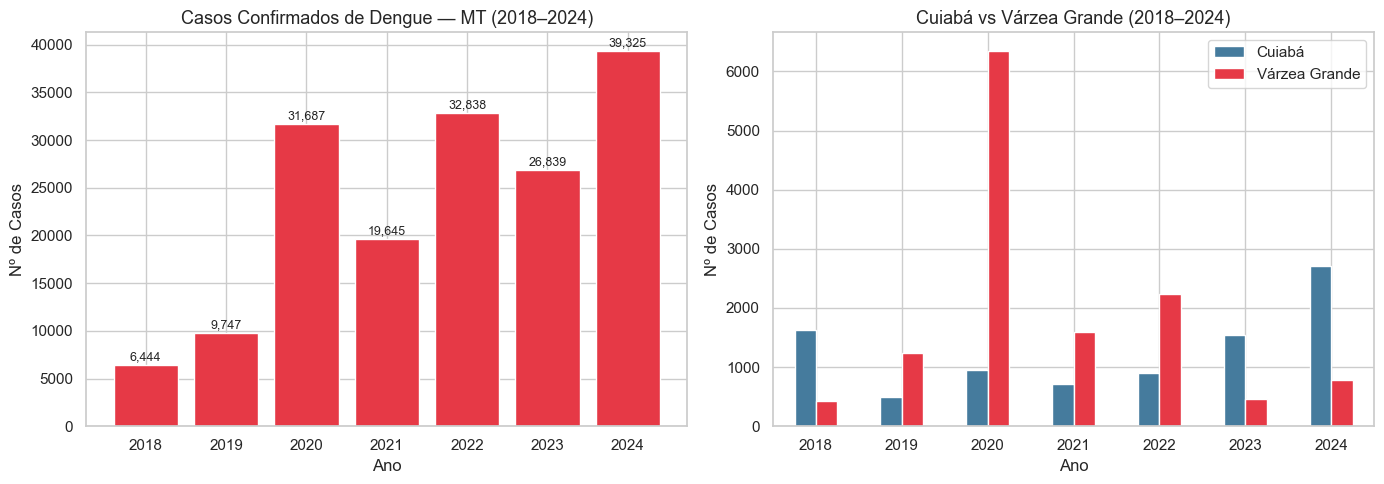

✅ Gráfico salvo em reports/fig01_casos_por_ano.png


In [6]:
# Converter datas
dengue['DT_NOTIFIC'] = pd.to_datetime(dengue['DT_NOTIFIC'])
dengue['DT_SIN_PRI'] = pd.to_datetime(dengue['DT_SIN_PRI'])

# Filtrar confirmados
confirmados = dengue[dengue['CLASSI_FIN'].isin(['10','11','12'])].copy()

# Casos por ano
casos_ano = confirmados.groupby('ano').size().reset_index(name='casos')

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1 — Casos por ano (MT)
axes[0].bar(casos_ano['ano'], casos_ano['casos'], color='#e63946', edgecolor='white')
axes[0].set_title('Casos Confirmados de Dengue — MT (2018–2024)', fontsize=13)
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Nº de Casos')
for i, row in casos_ano.iterrows():
    axes[0].text(row['ano'], row['casos'] + 500, f"{row['casos']:,}", 
                 ha='center', fontsize=9)

# 2 — Cuiabá vs Várzea Grande
cba_vg = confirmados[confirmados['ID_MUNICIP'].isin(['510340','510790'])]
cba_vg_ano = cba_vg.groupby(['ano','ID_MUNICIP']).size().unstack()
cba_vg_ano.columns = ['Cuiabá', 'Várzea Grande']
cba_vg_ano.plot(kind='bar', ax=axes[1], color=['#457b9d','#e63946'], edgecolor='white')
axes[1].set_title('Cuiabá vs Várzea Grande (2018–2024)', fontsize=13)
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Nº de Casos')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/fig01_casos_por_ano.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo em reports/fig01_casos_por_ano.png")

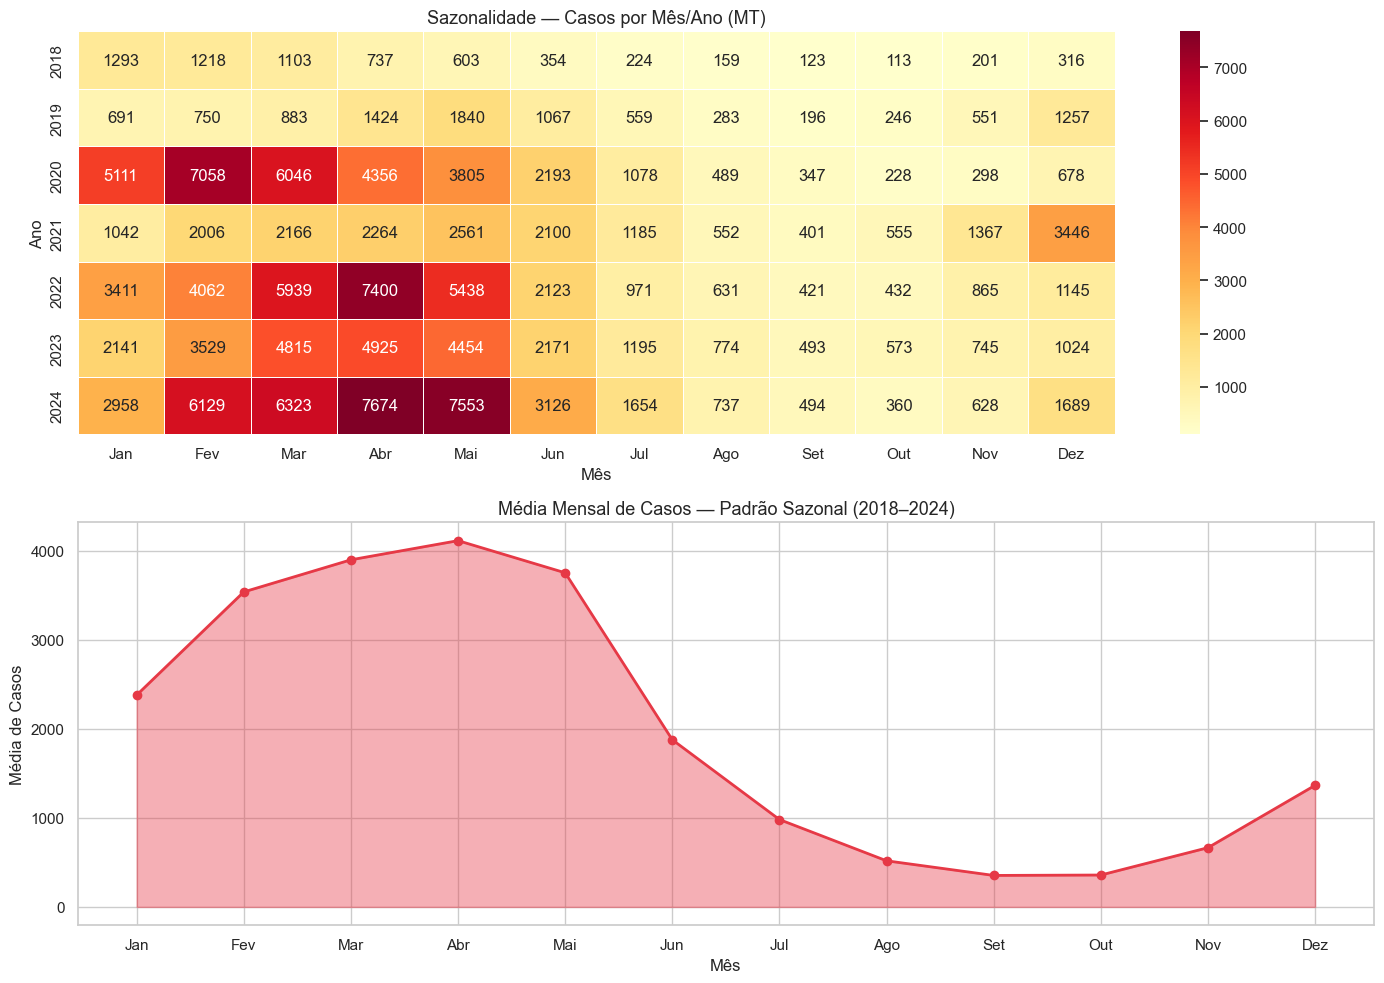

✅ Gráfico salvo em reports/fig02_sazonalidade.png


In [7]:
# Sazonalidade — casos por mês
confirmados['mes'] = confirmados['DT_NOTIFIC'].dt.month
confirmados['mes_nome'] = confirmados['DT_NOTIFIC'].dt.strftime('%b')

casos_mes_ano = confirmados.groupby(['ano','mes']).size().unstack(level=0)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1 — Heatmap de sazonalidade
import seaborn as sns
sns.heatmap(casos_mes_ano.T, 
            annot=True, fmt='.0f', 
            cmap='YlOrRd',
            ax=axes[0],
            linewidths=0.5)
axes[0].set_title('Sazonalidade — Casos por Mês/Ano (MT)', fontsize=13)
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Ano')
meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
axes[0].set_xticklabels(meses)

# 2 — Média mensal acumulada (padrão sazonal geral)
media_mes = confirmados.groupby('mes').size() / confirmados['ano'].nunique()
axes[1].fill_between(range(1,13), media_mes.values, alpha=0.4, color='#e63946')
axes[1].plot(range(1,13), media_mes.values, color='#e63946', linewidth=2, marker='o')
axes[1].set_title('Média Mensal de Casos — Padrão Sazonal (2018–2024)', fontsize=13)
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(meses)
axes[1].set_ylabel('Média de Casos')
axes[1].set_xlabel('Mês')

plt.tight_layout()
plt.savefig('../reports/fig02_sazonalidade.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo em reports/fig02_sazonalidade.png")

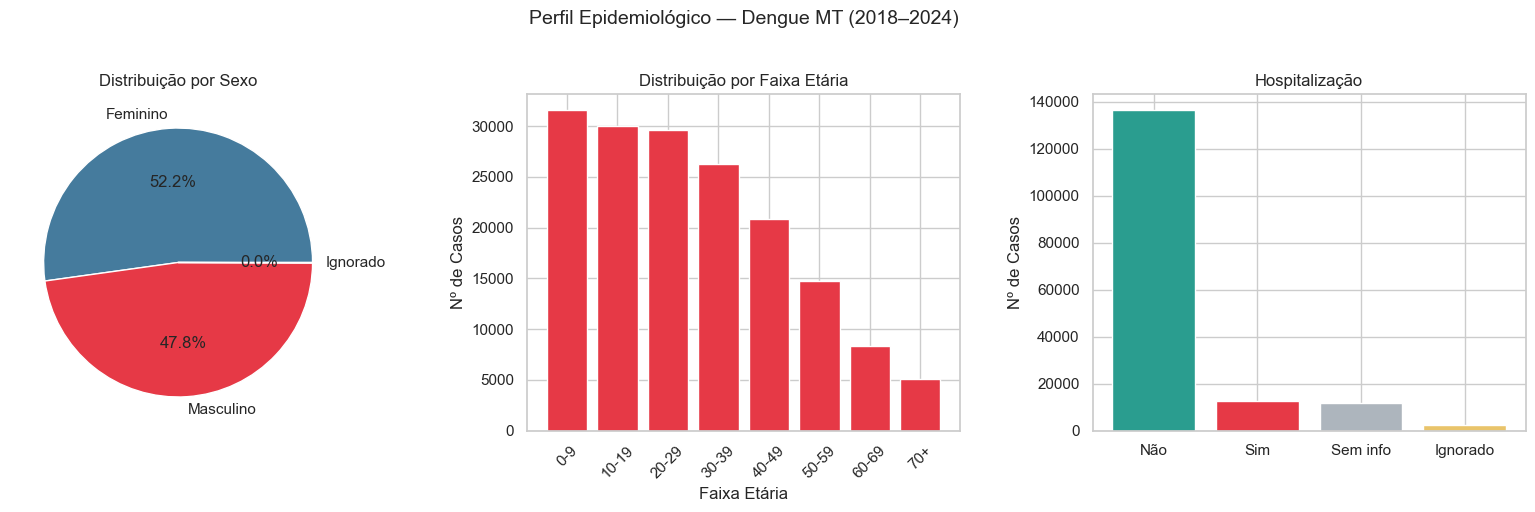

✅ Gráfico salvo em reports/fig03_perfil_epidemiologico.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1 — Sexo
sexo_map = {'M': 'Masculino', 'F': 'Feminino', 'I': 'Ignorado'}
sexo = confirmados['CS_SEXO'].map(sexo_map).value_counts()
axes[0].pie(sexo.values, labels=sexo.index, autopct='%1.1f%%',
            colors=['#457b9d','#e63946','#adb5bd'])
axes[0].set_title('Distribuição por Sexo')

# 2 — Faixa etária
def extrair_idade(valor):
    try:
        v = int(str(valor))
        if v >= 4000:
            return v - 4000
        elif v >= 3000:
            return (v - 3000) / 12
        elif v >= 2000:
            return (v - 2000) / 365
        return None
    except:
        return None

confirmados['IDADE_ANOS'] = confirmados['NU_IDADE_N'].apply(extrair_idade)
bins = [0, 10, 20, 30, 40, 50, 60, 70, 120]
labels_idade = ['0-9','10-19','20-29','30-39','40-49','50-59','60-69','70+']
confirmados['FAIXA_ETARIA'] = pd.cut(confirmados['IDADE_ANOS'], bins=bins, labels=labels_idade)
faixa = confirmados['FAIXA_ETARIA'].value_counts().sort_index()
axes[1].bar(faixa.index, faixa.values, color='#e63946', edgecolor='white')
axes[1].set_title('Distribuição por Faixa Etária')
axes[1].set_xlabel('Faixa Etária')
axes[1].set_ylabel('Nº de Casos')
axes[1].tick_params(axis='x', rotation=45)

# 3 — Hospitalização
hosp_map = {'1': 'Sim', '2': 'Não', '9': 'Ignorado', '': 'Sem info'}
hosp = confirmados['HOSPITALIZ'].map(hosp_map).value_counts()
cores_hosp = ['#2a9d8f','#e63946','#adb5bd','#e9c46a']
axes[2].bar(hosp.index, hosp.values, color=cores_hosp[:len(hosp)], edgecolor='white')
axes[2].set_title('Hospitalização')
axes[2].set_ylabel('Nº de Casos')

plt.suptitle('Perfil Epidemiológico — Dengue MT (2018–2024)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../reports/fig03_perfil_epidemiologico.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo em reports/fig03_perfil_epidemiologico.png")

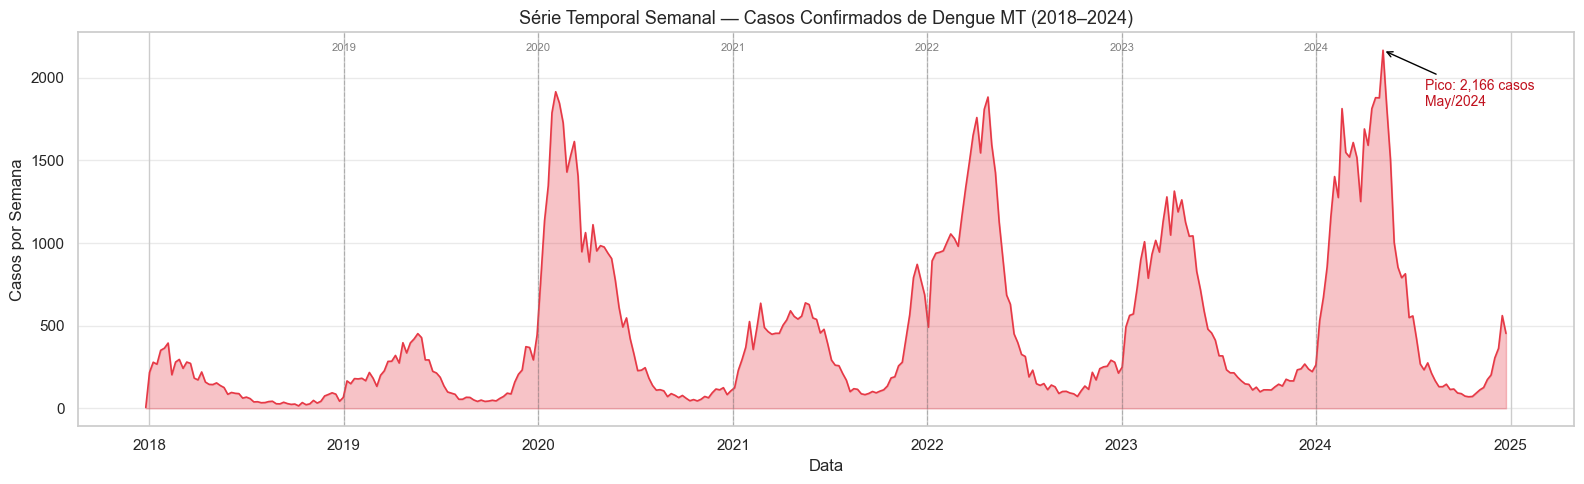

✅ Gráfico salvo em reports/fig04_serie_temporal.png


In [9]:
# Série temporal semanal — base do modelo preditivo
confirmados['semana'] = confirmados['DT_NOTIFIC'].dt.to_period('W').dt.start_time

serie_semanal = confirmados.groupby('semana').size().reset_index(name='casos')

fig, ax = plt.subplots(figsize=(16, 5))

ax.fill_between(serie_semanal['semana'], serie_semanal['casos'], 
                alpha=0.3, color='#e63946')
ax.plot(serie_semanal['semana'], serie_semanal['casos'], 
        color='#e63946', linewidth=1.2)

# Marcar picos
pico_idx = serie_semanal['casos'].idxmax()
pico = serie_semanal.loc[pico_idx]
ax.annotate(f"Pico: {pico['casos']:,} casos\n{pico['semana'].strftime('%b/%Y')}",
            xy=(pico['semana'], pico['casos']),
            xytext=(30, -40), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, color='#c1121f')

ax.set_title('Série Temporal Semanal — Casos Confirmados de Dengue MT (2018–2024)', fontsize=13)
ax.set_xlabel('Data')
ax.set_ylabel('Casos por Semana')
ax.grid(axis='y', alpha=0.4)

# Linhas verticais por ano
for ano in range(2019, 2025):
    ax.axvline(pd.Timestamp(f'{ano}-01-01'), color='gray', 
               linestyle='--', alpha=0.4, linewidth=0.8)
    ax.text(pd.Timestamp(f'{ano}-01-01'), ax.get_ylim()[1]*0.95, 
            str(ano), ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('../reports/fig04_serie_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo em reports/fig04_serie_temporal.png")

In [5]:
import zipfile, io, os
import pandas as pd
from pathlib import Path

PASTA_INMET = Path('../data/raw/inmet')
DESTINO = Path('../data/processed/inmet')
DESTINO.mkdir(parents=True, exist_ok=True)

ESTACOES_INTERESSE = ['A901']

COLUNAS_POSSIVEIS = {
    # 2018
    'DATA (YYYY-MM-DD)': 'data',
    'HORA (UTC)': 'hora',
    # 2019+
    'Data': 'data',
    'Hora UTC': 'hora',
    # variáveis climáticas (iguais nos dois formatos)
    'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'precipitacao_mm',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'temp_bulbo_seco',
    'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)': 'temp_max',
    'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)': 'temp_min',
    'UMIDADE RELATIVA DO AR, HORARIA (%)': 'umidade_rel',
    'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)': 'umidade_max',
    'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)': 'umidade_min',
}

dfs_anuais = []

for ano in range(2018, 2025):
    zip_path = PASTA_INMET / f'{ano}.zip'
    print(f"\n📦 Processando {ano}...")

    with zipfile.ZipFile(zip_path) as z:
        arquivos_mt = [f for f in z.namelist()
                       if any(f'_{e}_' in f for e in ESTACOES_INTERESSE)]

        for arq in arquivos_mt:
            estacao = [p for p in arq.split('_') if p.startswith('A')][0]
            cidade = arq.split('_')[4]

            with z.open(arq) as f:
                conteudo = io.TextIOWrapper(f, encoding='latin-1')
                df = pd.read_csv(conteudo, sep=';', skiprows=8,
                                 decimal=',', na_values=['-9999', '-9999.0', ''])

                # Remover colunas vazias
                df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
                df = df.dropna(how='all')

                # Renomear colunas
                rename_map = {k: v for k, v in COLUNAS_POSSIVEIS.items() if k in df.columns}
                df = df.rename(columns=rename_map)

                if 'data' not in df.columns:
                    print(f"    ⚠️  Coluna 'data' não encontrada em {arq} — colunas: {df.columns.tolist()[:5]}")
                    continue

                # Converter data (aceita ambos os formatos)
                df['data'] = pd.to_datetime(df['data'], errors='coerce')
                df = df.dropna(subset=['data'])

                # Agregar por dia
                agg_dict = {}
                if 'precipitacao_mm' in df.columns:
                    agg_dict['precipitacao_total'] = ('precipitacao_mm', 'sum')
                if 'temp_bulbo_seco' in df.columns:
                    agg_dict['temp_media'] = ('temp_bulbo_seco', 'mean')
                if 'temp_max' in df.columns:
                    agg_dict['temp_max'] = ('temp_max', 'max')
                if 'temp_min' in df.columns:
                    agg_dict['temp_min'] = ('temp_min', 'min')
                if 'umidade_rel' in df.columns:
                    agg_dict['umidade_media'] = ('umidade_rel', 'mean')
                if 'umidade_max' in df.columns:
                    agg_dict['umidade_max'] = ('umidade_max', 'max')
                if 'umidade_min' in df.columns:
                    agg_dict['umidade_min'] = ('umidade_min', 'min')

                agg = df.groupby('data').agg(**agg_dict).reset_index()
                agg['estacao'] = estacao
                agg['cidade'] = cidade
                agg['ano'] = ano
                dfs_anuais.append(agg)
                print(f"  ✅ {estacao} {cidade}: {len(agg)} dias")

inmet = pd.concat(dfs_anuais, ignore_index=True)
inmet.to_parquet(DESTINO / 'inmet_cuiaba_2018_2024.parquet', index=False)
print(f"\n🌡️ Dataset INMET salvo: {len(inmet):,} registros diários")
print(inmet.head())


📦 Processando 2018...
  ✅ A901 CUIABA: 365 dias

📦 Processando 2019...
  ✅ A901 CUIABA: 365 dias

📦 Processando 2020...
  ✅ A901 CUIABA: 366 dias

📦 Processando 2021...
  ✅ A901 CUIABA: 365 dias

📦 Processando 2022...
  ✅ A901 CUIABA: 365 dias

📦 Processando 2023...
  ✅ A901 CUIABA: 365 dias

📦 Processando 2024...
  ✅ A901 CUIABA: 366 dias

🌡️ Dataset INMET salvo: 2,557 registros diários
        data  precipitacao_total  temp_media  temp_max  temp_min  \
0 2018-01-01                 1.6   27.987500      33.1      24.4   
1 2018-01-02                 0.0   31.100000      33.6      26.5   
2 2018-01-03                 0.2   27.455556      29.8      25.2   
3 2018-01-04                 0.0   29.880000      32.9      23.5   
4 2018-01-05                 1.0   28.040000      29.7      25.2   

   umidade_media  umidade_max  umidade_min estacao  cidade   ano  
0      71.625000         85.0         49.0    A901  CUIABA  2018  
1      57.142857         73.0         47.0    A901  CUIABA  2018 

In [2]:
import os
print(os.getcwd())

C:\Users\edy85\OneDrive\Engenheiro-Cientista-Analista de dados\Projeto_Dengue_MT\notebooks


In [4]:
import zipfile, io, pandas as pd

with zipfile.ZipFile('../data/raw/inmet/2019.zip') as z:
    arquivos_mt = [f for f in z.namelist() if '_A901_' in f]
    with z.open(arquivos_mt[0]) as f:
        conteudo = io.TextIOWrapper(f, encoding='latin-1')
        for i, linha in enumerate(conteudo):
            print(repr(linha.strip()))
            if i >= 10: break

'REGI?O:;CO'
'UF:;MT'
'ESTAC?O:;CUIABA'
'CODIGO (WMO):;A901'
'LATITUDE:;-15,559295'
'LONGITUDE:;-56,062951'
'ALTITUDE:;241,56'
'DATA DE FUNDAC?O:;08/12/02'
'Data;Hora UTC;PRECIPITAÇÃO TOTAL, HORÁRIO (mm);PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB);PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB);PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB);RADIACAO GLOBAL (KJ/m²);TEMPERATURA DO AR - BULBO SECO, HORARIA (°C);TEMPERATURA DO PONTO DE ORVALHO (°C);TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C);TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C);TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C);TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C);UMIDADE REL. MAX. NA HORA ANT. (AUT) (%);UMIDADE REL. MIN. NA HORA ANT. (AUT) (%);UMIDADE RELATIVA DO AR, HORARIA (%);VENTO, DIREÇÃO HORARIA (gr) (° (gr));VENTO, RAJADA MAXIMA (m/s);VENTO, VELOCIDADE HORARIA (m/s);'
'2019/01/01;0000 UTC;0;983,2;983,2;981,5;;23,5;22,3;23,6;23,5;22,4;22,3;93;93;93;356;3,1;1,4;'
'2019/01/01;0100 UTC;0;983,9;984;983,2;;23,5

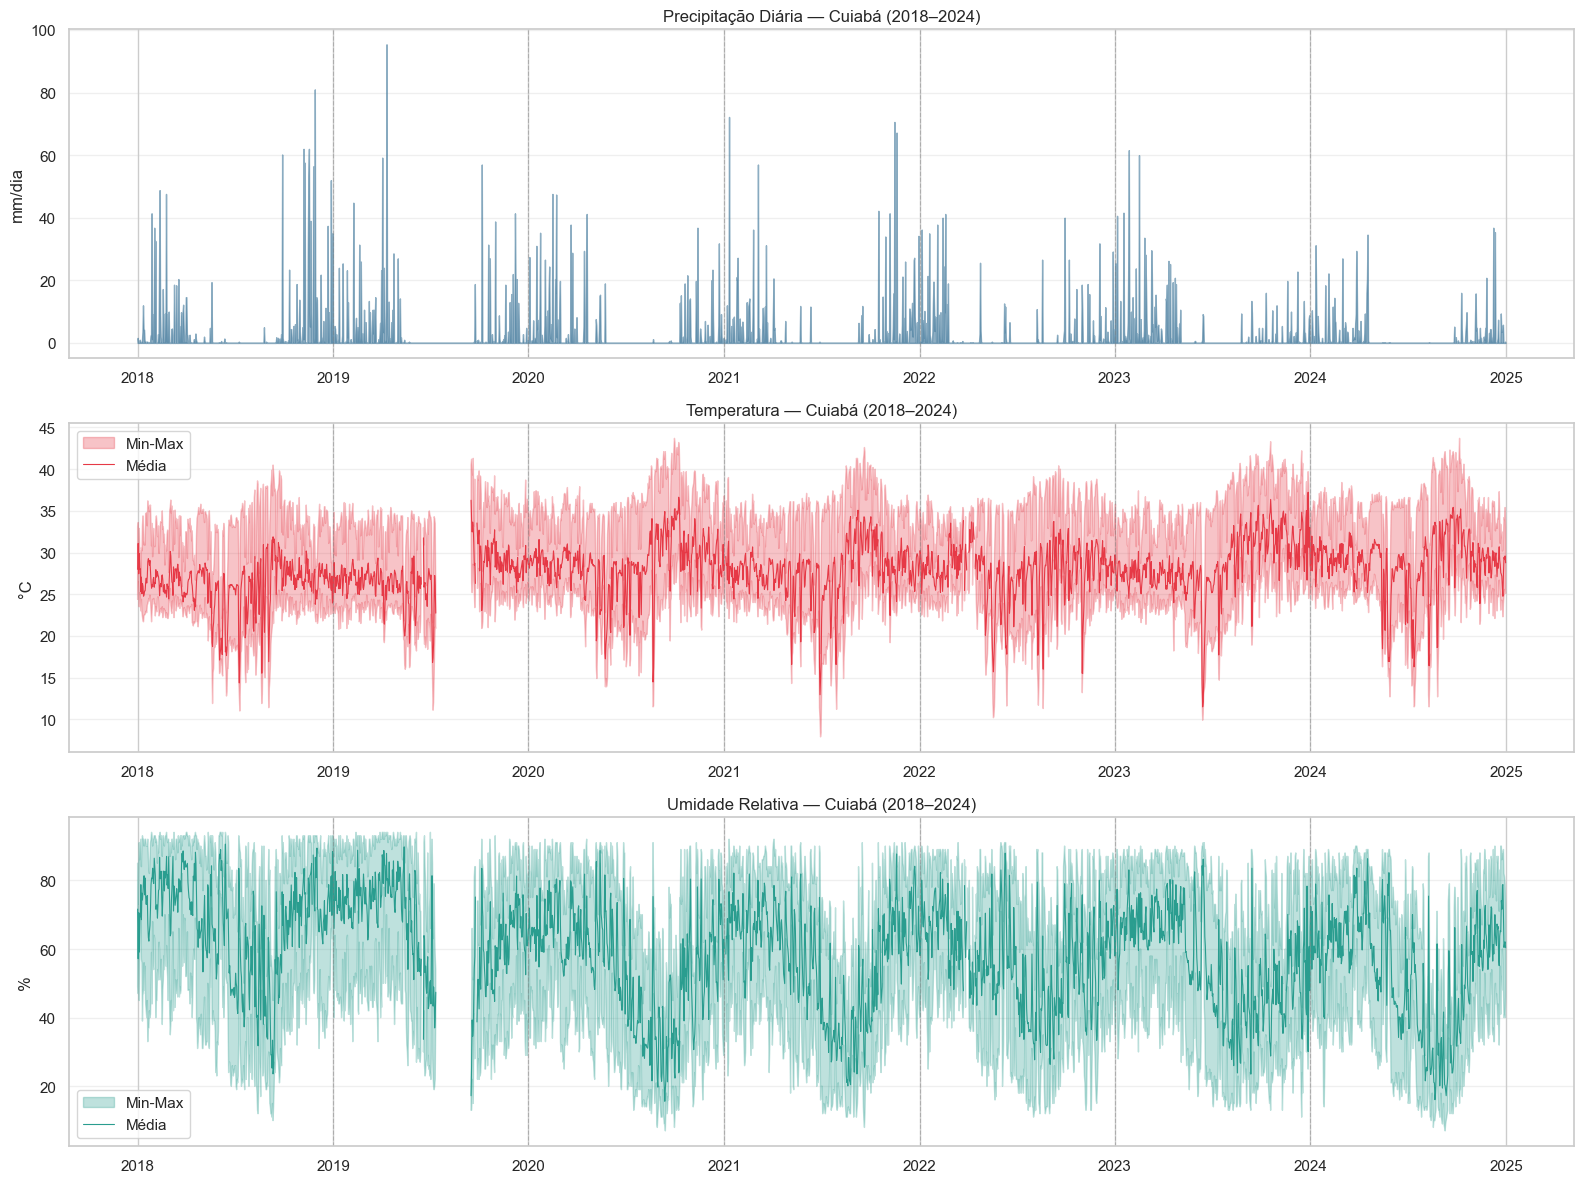

✅ Gráfico salvo!


In [8]:
# Carregar dados INMET
inmet = pd.read_parquet('../data/processed/inmet/inmet_cuiaba_2018_2024.parquet')

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# 1 — Precipitação
axes[0].fill_between(inmet['data'], inmet['precipitacao_total'], 
                     alpha=0.6, color='#457b9d')
axes[0].set_title('Precipitação Diária — Cuiabá (2018–2024)', fontsize=12)
axes[0].set_ylabel('mm/dia')

# 2 — Temperatura
axes[1].fill_between(inmet['data'], inmet['temp_min'], inmet['temp_max'],
                     alpha=0.3, color='#e63946', label='Min-Max')
axes[1].plot(inmet['data'], inmet['temp_media'], 
             color='#e63946', linewidth=0.8, label='Média')
axes[1].set_title('Temperatura — Cuiabá (2018–2024)', fontsize=12)
axes[1].set_ylabel('°C')
axes[1].legend()

# 3 — Umidade
axes[2].fill_between(inmet['data'], inmet['umidade_min'], inmet['umidade_max'],
                     alpha=0.3, color='#2a9d8f', label='Min-Max')
axes[2].plot(inmet['data'], inmet['umidade_media'], 
             color='#2a9d8f', linewidth=0.8, label='Média')
axes[2].set_title('Umidade Relativa — Cuiabá (2018–2024)', fontsize=12)
axes[2].set_ylabel('%')
axes[2].legend()

for ax in axes:
    ax.grid(axis='y', alpha=0.3)
    for ano in range(2019, 2025):
        ax.axvline(pd.Timestamp(f'{ano}-01-01'), color='gray', 
                   linestyle='--', alpha=0.4, linewidth=0.8)

plt.tight_layout()
plt.savefig('../reports/fig05_clima_cuiaba.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo!")

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

print("✅ Libs carregadas!")

✅ Libs carregadas!


In [9]:
# Carregar SINAN já processado
from pathlib import Path

sinan_path = Path('../data/processed/sinan')
dfs = []
for arq in sorted(sinan_path.glob('*.parquet')):
    df = pd.read_parquet(arq)
    df['ano'] = int(arq.stem.split('_')[-1])
    dfs.append(df)

dengue = pd.concat(dfs, ignore_index=True)

# Filtrar confirmados
confirmados = dengue[dengue['CLASSI_FIN'].isin(['10','11','12'])].copy()
confirmados['DT_NOTIFIC'] = pd.to_datetime(confirmados['DT_NOTIFIC'])

# Agregar casos por dia
casos_dia = confirmados.groupby('DT_NOTIFIC').size().reset_index(name='casos')
casos_dia = casos_dia.rename(columns={'DT_NOTIFIC': 'data'})

# Carregar INMET
inmet = pd.read_parquet('../data/processed/inmet/inmet_cuiaba_2018_2024.parquet')

# Merge por data
df_merged = pd.merge(casos_dia, inmet, on='data', how='inner')
df_merged = df_merged.sort_values('data').reset_index(drop=True)

# Salvar
df_merged.to_parquet('../data/processed/dengue_clima_merged.parquet', index=False)

print(f"✅ Merge concluído: {len(df_merged):,} dias com dados completos")
print(f"   Período: {df_merged['data'].min().date()} → {df_merged['data'].max().date()}")
print(f"\n📋 Colunas disponíveis:")
print(df_merged.columns.tolist())
print(df_merged.head())

✅ Merge concluído: 2,538 dias com dados completos
   Período: 2018-01-01 → 2024-12-28

📋 Colunas disponíveis:
['data', 'casos', 'precipitacao_total', 'temp_media', 'temp_max', 'temp_min', 'umidade_media', 'umidade_max', 'umidade_min', 'estacao', 'cidade', 'ano']
        data  casos  precipitacao_total  temp_media  temp_max  temp_min  \
0 2018-01-01     13                 1.6   27.987500      33.1      24.4   
1 2018-01-02     24                 0.0   31.100000      33.6      26.5   
2 2018-01-03     24                 0.2   27.455556      29.8      25.2   
3 2018-01-04     49                 0.0   29.880000      32.9      23.5   
4 2018-01-05     46                 1.0   28.040000      29.7      25.2   

   umidade_media  umidade_max  umidade_min estacao  cidade   ano  
0      71.625000         85.0         49.0    A901  CUIABA  2018  
1      57.142857         73.0         47.0    A901  CUIABA  2018  
2      70.555556         84.0         59.0    A901  CUIABA  2018  
3      59.100000  

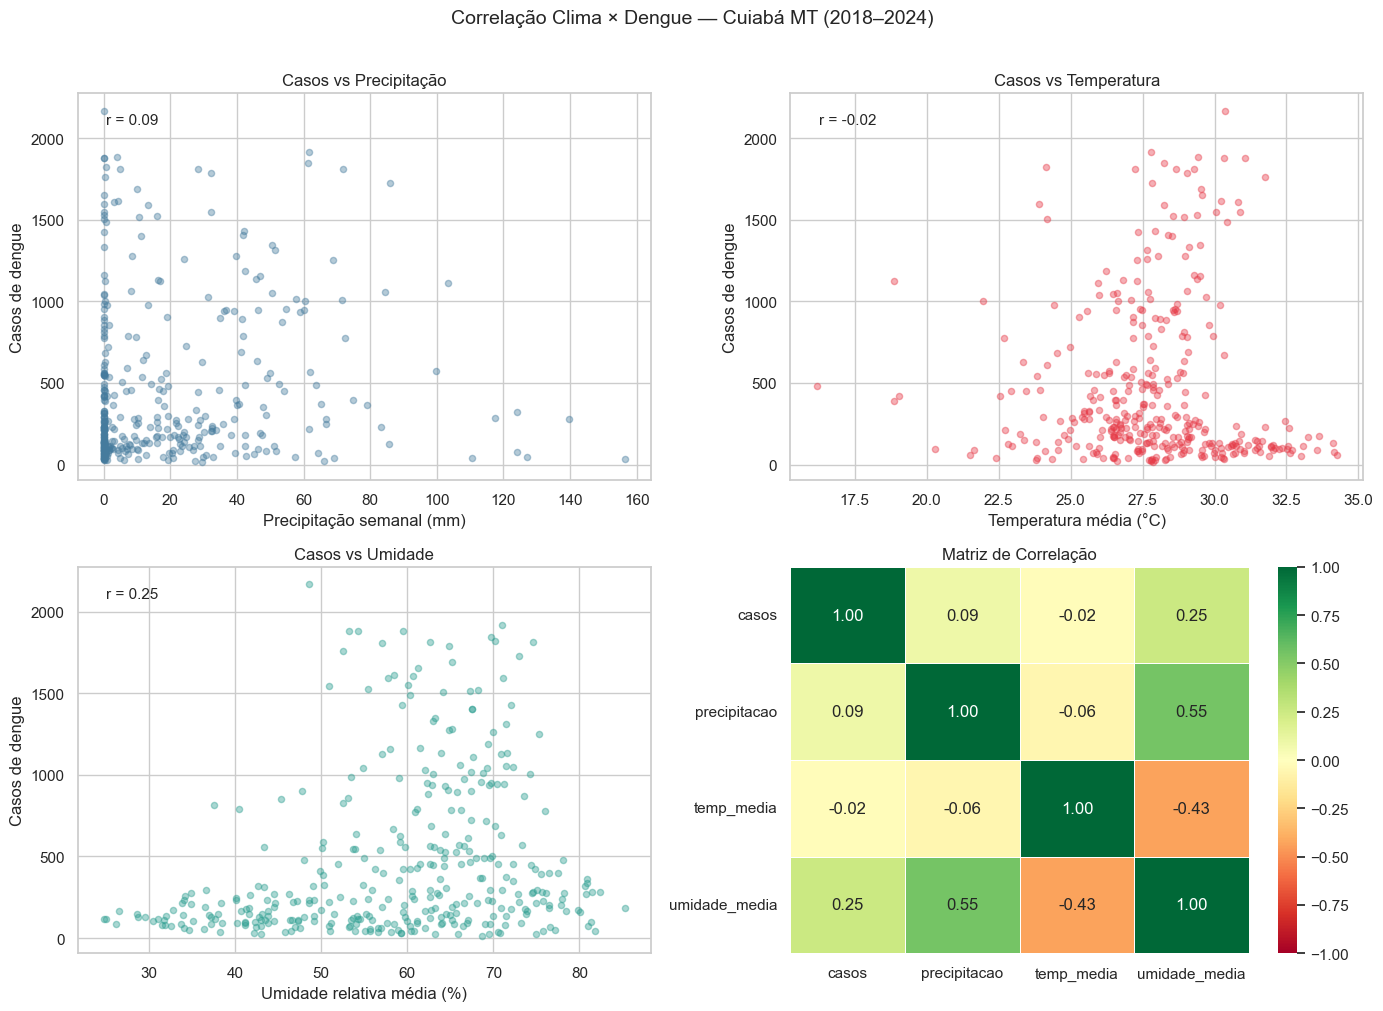

✅ Gráfico salvo!


In [10]:
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Agregar por semana para suavizar
df_merged['semana'] = df_merged['data'].dt.to_period('W').dt.start_time
semanal = df_merged.groupby('semana').agg(
    casos=('casos', 'sum'),
    precipitacao=('precipitacao_total', 'sum'),
    temp_media=('temp_media', 'mean'),
    umidade_media=('umidade_media', 'mean')
).reset_index()

# 1 — Casos vs Precipitação
axes[0,0].scatter(semanal['precipitacao'], semanal['casos'], 
                  alpha=0.4, color='#457b9d', s=20)
axes[0,0].set_xlabel('Precipitação semanal (mm)')
axes[0,0].set_ylabel('Casos de dengue')
axes[0,0].set_title('Casos vs Precipitação')
corr1 = semanal['casos'].corr(semanal['precipitacao'])
axes[0,0].text(0.05, 0.92, f'r = {corr1:.2f}', transform=axes[0,0].transAxes, fontsize=11)

# 2 — Casos vs Temperatura
axes[0,1].scatter(semanal['temp_media'], semanal['casos'], 
                  alpha=0.4, color='#e63946', s=20)
axes[0,1].set_xlabel('Temperatura média (°C)')
axes[0,1].set_ylabel('Casos de dengue')
axes[0,1].set_title('Casos vs Temperatura')
corr2 = semanal['casos'].corr(semanal['temp_media'])
axes[0,1].text(0.05, 0.92, f'r = {corr2:.2f}', transform=axes[0,1].transAxes, fontsize=11)

# 3 — Casos vs Umidade
axes[1,0].scatter(semanal['umidade_media'], semanal['casos'], 
                  alpha=0.4, color='#2a9d8f', s=20)
axes[1,0].set_xlabel('Umidade relativa média (%)')
axes[1,0].set_ylabel('Casos de dengue')
axes[1,0].set_title('Casos vs Umidade')
corr3 = semanal['casos'].corr(semanal['umidade_media'])
axes[1,0].text(0.05, 0.92, f'r = {corr3:.2f}', transform=axes[1,0].transAxes, fontsize=11)

# 4 — Heatmap correlação
variaveis = ['casos','precipitacao','temp_media','umidade_media']
corr_matrix = semanal[variaveis].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[1,1], vmin=-1, vmax=1, linewidths=0.5)
axes[1,1].set_title('Matriz de Correlação')

plt.suptitle('Correlação Clima × Dengue — Cuiabá MT (2018–2024)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../reports/fig06_correlacao_clima_dengue.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo!")

 lag_semanas  r_precipitacao  r_umidade  r_temperatura
           0        0.079157   0.252894      -0.021071
           1        0.120477   0.279293       0.018358
           2        0.147886   0.298264       0.060202
           3        0.194952   0.322314       0.083106
           4        0.213652   0.337720       0.109032
           5        0.225279   0.340917       0.141576
           6        0.257019   0.342789       0.166128
           7        0.254885   0.330231       0.200144


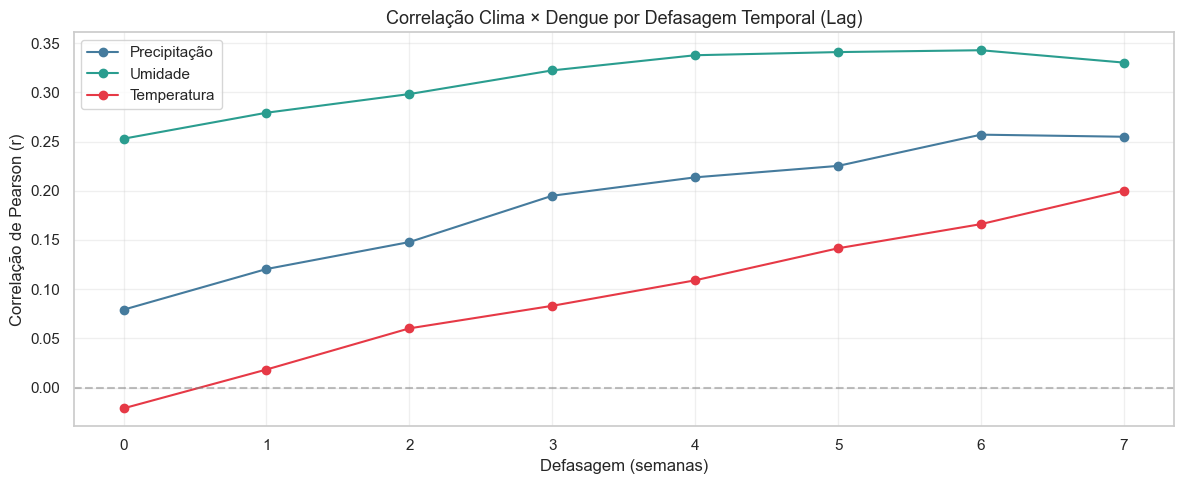

In [11]:
# Testar correlação com diferentes defasagens (lags)
resultados_lag = []

for lag in range(0, 8):  # 0 a 7 semanas de defasagem
    semanal_lag = semanal.copy()
    semanal_lag['precipitacao_lag'] = semanal_lag['precipitacao'].shift(lag)
    semanal_lag['umidade_lag'] = semanal_lag['umidade_media'].shift(lag)
    semanal_lag['temp_lag'] = semanal_lag['temp_media'].shift(lag)
    semanal_lag = semanal_lag.dropna()
    
    resultados_lag.append({
        'lag_semanas': lag,
        'r_precipitacao': semanal_lag['casos'].corr(semanal_lag['precipitacao_lag']),
        'r_umidade': semanal_lag['casos'].corr(semanal_lag['umidade_lag']),
        'r_temperatura': semanal_lag['casos'].corr(semanal_lag['temp_lag']),
    })

lag_df = pd.DataFrame(resultados_lag)
print(lag_df.to_string(index=False))

# Gráfico
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(lag_df['lag_semanas'], lag_df['r_precipitacao'], 
        marker='o', label='Precipitação', color='#457b9d')
ax.plot(lag_df['lag_semanas'], lag_df['r_umidade'], 
        marker='o', label='Umidade', color='#2a9d8f')
ax.plot(lag_df['lag_semanas'], lag_df['r_temperatura'], 
        marker='o', label='Temperatura', color='#e63946')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Defasagem (semanas)')
ax.set_ylabel('Correlação de Pearson (r)')
ax.set_title('Correlação Clima × Dengue por Defasagem Temporal (Lag)', fontsize=13)
ax.legend()
ax.set_xticks(range(0, 8))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/fig07_correlacao_lag.png', dpi=150, bbox_inches='tight')
plt.show()

In [1]:
import pandas as pd

# Carregar dados GEE
gee = pd.read_csv('../data/raw/gee/ndvi_ndwi_mensal_2018_2024.csv')
print(f"Shape: {gee.shape}")
print(f"\nColunas: {gee.columns.tolist()}")
print(f"\nAmostra:")
print(gee.head(10))

Shape: (84, 8)

Colunas: ['system:index', 'ano', 'data', 'mes', 'n_imagens', 'ndvi_medio', 'ndwi_medio', '.geo']

Amostra:
   system:index     ano     data   mes  n_imagens   ndvi_medio   ndwi_medio  \
0             0  2018.0  2018-01   1.0          0 -9999.000000 -9999.000000   
1             1  2018.0  2018-02   2.0          0 -9999.000000 -9999.000000   
2             2  2018.0  2018-03   3.0          0 -9999.000000 -9999.000000   
3             3  2018.0  2018-04   4.0          0 -9999.000000 -9999.000000   
4             4  2018.0  2018-05   5.0          4     0.607621    -0.604785   
5             5  2018.0  2018-06   6.0          1     0.655926    -0.627611   
6             6  2018.0  2018-07   7.0          5     0.497381    -0.552747   
7             7  2018.0  2018-08   8.0          0 -9999.000000 -9999.000000   
8             8  2018.0  2018-09   9.0          0 -9999.000000 -9999.000000   
9             9  2018.0  2018-10  10.0          0 -9999.000000 -9999.000000   

       

In [2]:
# Verificar cobertura de dados
print("Meses com dados válidos:", (gee['n_imagens'] > 0).sum(), "de 84")
print("Meses sem dados (-9999):", (gee['n_imagens'] == 0).sum(), "de 84")

print("\nCobertura por ano:")
print(gee.groupby('ano')['n_imagens'].apply(lambda x: (x>0).sum()).rename('meses_validos'))

print("\nCobertura por mês (todos os anos):")
print(gee.groupby('mes')['n_imagens'].apply(lambda x: (x>0).sum()).rename('anos_com_dados'))

Meses com dados válidos: 71 de 84
Meses sem dados (-9999): 13 de 84

Cobertura por ano:
ano
2018.0     4
2019.0    12
2020.0    11
2021.0    12
2022.0    12
2023.0    11
2024.0     9
Name: meses_validos, dtype: int64

Cobertura por mês (todos os anos):
mes
1.0     5
2.0     4
3.0     6
4.0     6
5.0     7
6.0     7
7.0     7
8.0     6
9.0     6
10.0    6
11.0    5
12.0    6
Name: anos_com_dados, dtype: int64


In [3]:
import numpy as np

# Limpar e processar
gee_clean = gee[['ano', 'mes', 'data', 'n_imagens', 'ndvi_medio', 'ndwi_medio']].copy()

# Substituir -9999 por NaN
gee_clean['ndvi_medio'] = gee_clean['ndvi_medio'].replace(-9999.0, np.nan)
gee_clean['ndwi_medio'] = gee_clean['ndwi_medio'].replace(-9999.0, np.nan)

# Converter data
gee_clean['data'] = pd.to_datetime(gee_clean['data'], format='%Y-%m')

# Interpolação linear para preencher lacunas
gee_clean = gee_clean.sort_values('data').reset_index(drop=True)
gee_clean['ndvi_medio'] = gee_clean['ndvi_medio'].interpolate(method='linear')
gee_clean['ndwi_medio'] = gee_clean['ndwi_medio'].interpolate(method='linear')

print(f"Nulos restantes: {gee_clean[['ndvi_medio','ndwi_medio']].isnull().sum().sum()}")
print(f"\nAmostra:")
print(gee_clean.head(12))

# Salvar
gee_clean.to_parquet('../data/processed/gee_ndvi_ndwi_2018_2024.parquet', index=False)
print("\n✅ Salvo em data/processed/gee_ndvi_ndwi_2018_2024.parquet")

Nulos restantes: 8

Amostra:
       ano   mes       data  n_imagens  ndvi_medio  ndwi_medio
0   2018.0   1.0 2018-01-01          0         NaN         NaN
1   2018.0   2.0 2018-02-01          0         NaN         NaN
2   2018.0   3.0 2018-03-01          0         NaN         NaN
3   2018.0   4.0 2018-04-01          0         NaN         NaN
4   2018.0   5.0 2018-05-01          4    0.607621   -0.604785
5   2018.0   6.0 2018-06-01          1    0.655926   -0.627611
6   2018.0   7.0 2018-07-01          5    0.497381   -0.552747
7   2018.0   8.0 2018-08-01          0    0.521806   -0.559522
8   2018.0   9.0 2018-09-01          0    0.546231   -0.566298
9   2018.0  10.0 2018-10-01          0    0.570657   -0.573073
10  2018.0  11.0 2018-11-01          0    0.595082   -0.579848
11  2018.0  12.0 2018-12-01          4    0.619507   -0.586624

✅ Salvo em data/processed/gee_ndvi_ndwi_2018_2024.parquet


In [4]:
# Imputação sazonal — média do mesmo mês nos outros anos
gee_clean2 = gee[['ano', 'mes', 'data', 'n_imagens', 'ndvi_medio', 'ndwi_medio']].copy()
gee_clean2['ndvi_medio'] = gee_clean2['ndvi_medio'].replace(-9999.0, np.nan)
gee_clean2['ndwi_medio'] = gee_clean2['ndwi_medio'].replace(-9999.0, np.nan)
gee_clean2['data'] = pd.to_datetime(gee_clean2['data'], format='%Y-%m')
gee_clean2 = gee_clean2.sort_values('data').reset_index(drop=True)

# Calcular média por mês (excluindo NaN)
media_mensal = gee_clean2.groupby('mes')[['ndvi_medio','ndwi_medio']].mean()
print("Médias sazonais por mês:")
print(media_mensal.round(4))

# Preencher NaN com média do mesmo mês
for idx, row in gee_clean2.iterrows():
    if pd.isna(row['ndvi_medio']):
        gee_clean2.at[idx, 'ndvi_medio'] = media_mensal.loc[row['mes'], 'ndvi_medio']
    if pd.isna(row['ndwi_medio']):
        gee_clean2.at[idx, 'ndwi_medio'] = media_mensal.loc[row['mes'], 'ndwi_medio']

print(f"\nNulos restantes: {gee_clean2[['ndvi_medio','ndwi_medio']].isnull().sum().sum()}")
print(f"\nPrimeiros 12 meses:")
print(gee_clean2.head(12))

# Salvar
gee_clean2.to_parquet('../data/processed/gee_ndvi_ndwi_2018_2024.parquet', index=False)
print("\n✅ Salvo com imputação sazonal!")

Médias sazonais por mês:
      ndvi_medio  ndwi_medio
mes                         
1.0       0.5054     -0.4725
2.0       0.5947     -0.5549
3.0       0.6039     -0.5689
4.0       0.6122     -0.5820
5.0       0.5836     -0.5794
6.0       0.5281     -0.5538
7.0       0.4268     -0.4995
8.0       0.3310     -0.4355
9.0       0.3050     -0.4060
10.0      0.3432     -0.3901
11.0      0.4867     -0.4840
12.0      0.5579     -0.5354

Nulos restantes: 0

Primeiros 12 meses:
       ano   mes       data  n_imagens  ndvi_medio  ndwi_medio
0   2018.0   1.0 2018-01-01          0    0.505364   -0.472531
1   2018.0   2.0 2018-02-01          0    0.594697   -0.554930
2   2018.0   3.0 2018-03-01          0    0.603851   -0.568866
3   2018.0   4.0 2018-04-01          0    0.612241   -0.582031
4   2018.0   5.0 2018-05-01          4    0.607621   -0.604785
5   2018.0   6.0 2018-06-01          1    0.655926   -0.627611
6   2018.0   7.0 2018-07-01          5    0.497381   -0.552747
7   2018.0   8.0 2018-08

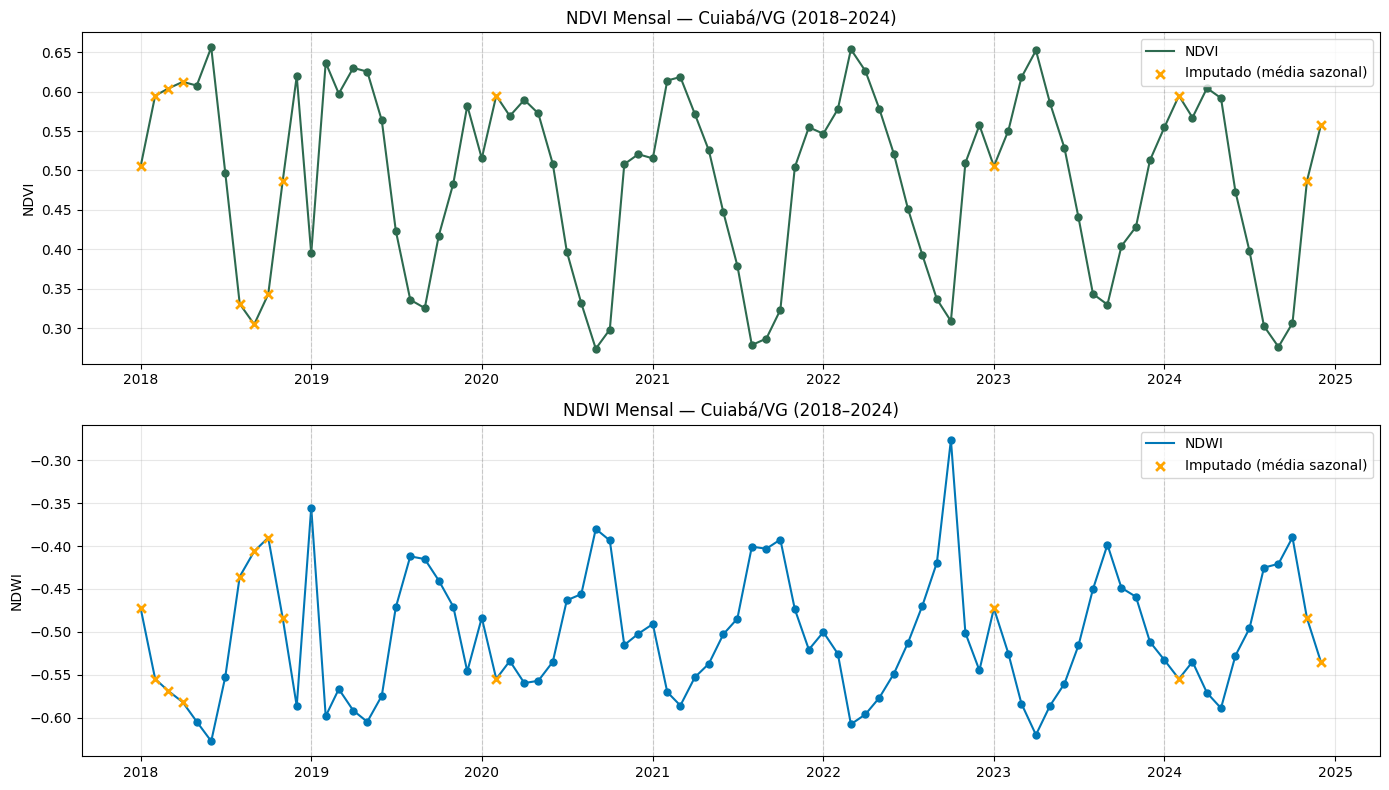

✅ Gráfico salvo!


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Separar dados reais e imputados
reais = gee_clean2[gee_clean2['n_imagens'] > 0]
imputados = gee_clean2[gee_clean2['n_imagens'] == 0]

# 1 — NDVI
axes[0].plot(gee_clean2['data'], gee_clean2['ndvi_medio'], 
             color='#2d6a4f', linewidth=1.5, label='NDVI')
axes[0].scatter(reais['data'], reais['ndvi_medio'], 
                color='#2d6a4f', s=25, zorder=5)
axes[0].scatter(imputados['data'], imputados['ndvi_medio'], 
                color='orange', s=40, marker='x', zorder=5, 
                linewidths=2, label='Imputado (média sazonal)')
axes[0].set_title('NDVI Mensal — Cuiabá/VG (2018–2024)', fontsize=12)
axes[0].set_ylabel('NDVI')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2 — NDWI
axes[1].plot(gee_clean2['data'], gee_clean2['ndwi_medio'], 
             color='#0077b6', linewidth=1.5, label='NDWI')
axes[1].scatter(reais['data'], reais['ndwi_medio'], 
                color='#0077b6', s=25, zorder=5)
axes[1].scatter(imputados['data'], imputados['ndwi_medio'], 
                color='orange', s=40, marker='x', zorder=5,
                linewidths=2, label='Imputado (média sazonal)')
axes[1].set_title('NDWI Mensal — Cuiabá/VG (2018–2024)', fontsize=12)
axes[1].set_ylabel('NDWI')
axes[1].legend()
axes[1].grid(alpha=0.3)

for ax in axes:
    for ano in range(2019, 2025):
        ax.axvline(pd.Timestamp(f'{ano}-01-01'), color='gray', 
                   linestyle='--', alpha=0.3, linewidth=0.8)

plt.tight_layout()
plt.savefig('../reports/fig08_ndvi_ndwi_mensal.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo!")

In [1]:
import pandas as pd
import numpy as np

# Carregar dataset blend S2 + MODIS
blend = pd.read_csv('../data/raw/gee/ndvi_ndwi_blend_2018_2024.csv')
print(f"Shape: {blend.shape}")
print(f"\nColunas: {blend.columns.tolist()}")
print(f"\nFontes de dados:")
print(blend['fonte'].value_counts())
print(f"\nAmostra:")
print(blend[['ano','mes','data','ndvi_final','ndwi_final','fonte','n_s2','n_modis']].head(12))

Shape: (84, 10)

Colunas: ['system:index', 'ano', 'data', 'fonte', 'mes', 'n_modis', 'n_s2', 'ndvi_final', 'ndwi_final', '.geo']

Fontes de dados:
fonte
sentinel2    71
modis        13
Name: count, dtype: int64

Amostra:
       ano   mes     data  ndvi_final  ndwi_final      fonte  n_s2  n_modis
0   2018.0   1.0  2018-01    0.650663         NaN      modis     0        1
1   2018.0   2.0  2018-02    0.649900         NaN      modis     0        1
2   2018.0   3.0  2018-03    0.653117         NaN      modis     0        1
3   2018.0   4.0  2018-04    0.666835         NaN      modis     0        1
4   2018.0   5.0  2018-05    0.607621   -0.604785  sentinel2     4        1
5   2018.0   6.0  2018-06    0.655926   -0.627611  sentinel2     1        1
6   2018.0   7.0  2018-07    0.497381   -0.552747  sentinel2     5        1
7   2018.0   8.0  2018-08    0.428434         NaN      modis     0        1
8   2018.0   9.0  2018-09    0.413695         NaN      modis     0        1
9   2018.0  10.0  2

In [2]:
# Limpar e processar dataset blend
gee_blend = blend[['ano','mes','data','ndvi_final','ndwi_final','fonte','n_s2','n_modis']].copy()
gee_blend['data'] = pd.to_datetime(gee_blend['data'], format='%Y-%m')
gee_blend = gee_blend.sort_values('data').reset_index(drop=True)

print(f"NaNs antes: NDVI={gee_blend['ndvi_final'].isna().sum()}, NDWI={gee_blend['ndwi_final'].isna().sum()}")

# NDVI — já completo via MODIS, sem NaN
# NDWI — imputação sazonal apenas para meses MODIS
media_ndwi_mensal = gee_blend.groupby('mes')['ndwi_final'].mean()

for idx, row in gee_blend.iterrows():
    if pd.isna(row['ndwi_final']):
        gee_blend.at[idx, 'ndwi_final'] = media_ndwi_mensal.loc[row['mes']]

print(f"NaNs depois: NDVI={gee_blend['ndvi_final'].isna().sum()}, NDWI={gee_blend['ndwi_final'].isna().sum()}")

# Salvar
gee_blend.to_parquet('../data/processed/gee_ndvi_ndwi_blend_2018_2024.parquet', index=False)
print(f"\n✅ Dataset blend salvo!")
print(f"\nResumo de fontes:")
print(gee_blend['fonte'].value_counts())
print(f"\nAmostra final:")
print(gee_blend.head(12))

NaNs antes: NDVI=0, NDWI=13
NaNs depois: NDVI=0, NDWI=0

✅ Dataset blend salvo!

Resumo de fontes:
fonte
sentinel2    71
modis        13
Name: count, dtype: int64

Amostra final:
       ano   mes       data  ndvi_final  ndwi_final      fonte  n_s2  n_modis
0   2018.0   1.0 2018-01-01    0.650663   -0.472531      modis     0        1
1   2018.0   2.0 2018-02-01    0.649900   -0.554930      modis     0        1
2   2018.0   3.0 2018-03-01    0.653117   -0.568866      modis     0        1
3   2018.0   4.0 2018-04-01    0.666835   -0.582031      modis     0        1
4   2018.0   5.0 2018-05-01    0.607621   -0.604785  sentinel2     4        1
5   2018.0   6.0 2018-06-01    0.655926   -0.627611  sentinel2     1        1
6   2018.0   7.0 2018-07-01    0.497381   -0.552747  sentinel2     5        1
7   2018.0   8.0 2018-08-01    0.428434   -0.435507      modis     0        1
8   2018.0   9.0 2018-09-01    0.413695   -0.406049      modis     0        1
9   2018.0  10.0 2018-10-01    0.576850  